# Evaluación de una prueba A/B sistema de recomendaciones

## Contexto Previo

Has recibido una tarea analítica de una tienda en línea internacional. Tus predecesores no consiguieron completarla: lanzaron una prueba A/B y luego abandonaron (para iniciar una granja de sandías en Brasil). Solo dejaron las especificaciones técnicas y los resultados de las pruebas.

## Descripción técnica
- Nombre de la prueba: `recommender_system_test`
- Grupos: А (control), B (nuevo embudo de pago)
- Launch date: 2020-12-07
- Fecha en la que dejaron de aceptar nuevos usuarios: 2020-12-21
- Fecha de finalización: 2021-01-01
- Audiencia: 15% de los nuevos usuarios de la región de la UE
- Propósito de la prueba: probar cambios relacionados con la introducción de un sistema de recomendaciones mejorado
- Resultado esperado: dentro de los 14 días posteriores a la inscripción, los usuarios mostrarán una mejor conversión en vistas de la página del producto (el evento `product_page`), instancias de agregar artículos al carrito de compras (`product_cart`, denominado `product_card` en la descripción original) y compras (`purchase`). En cada etapa del embudo `product_page → product_cart → purchase`, habrá al menos un 10% de aumento.
- Número previsto de participantes de la prueba: 6 000

## Descripción de los datos

El proyecto utiliza cuatro fuentes de datos para validar la ejecución de la prueba A/B, analizar la actividad de los usuarios y evaluar los resultados experimentales.

`ab_project_marketing_events_us.csv` <br>
Calendario de eventos de marketing correspondientes a 2020.
Campos:
- `name`: nombre del evento de marketing.
- `regions`: regiones donde se llevará a cabo la campaña publicitaria.
- `start_dt`: fecha de inicio de la campaña.
- `finish_dt`: fecha de finalización de la campaña.

`final_ab_new_users_upd_us.csv` <br>
Contiene todos los usuarios que se registraron en la tienda en línea entre el 7 y el 21 de diciembre de 2020. <br>
Campos:
- `user_id`
- `first_date`: fecha de inscripción.
- `region`
- `device`: dispositivo utilizado para la inscripción.

`final_ab_events_upd_us.csv` <br>
Contiene todos los eventos de los nuevos usuarios registrados entre el 7 de diciembre de 2020 y el 1 de enero de 2021. <br>
Campos:
- `user_id`
- `event_dt`: fecha y hora del evento.
- `event_name`: nombre del tipo de evento.
- `details`: información adicional sobre el evento, como el pedido total en USD para eventos `purchase`.

`final_ab_participants_upd_us.csv` <br>
Contiene la información de los participantes y su asignación a los grupos de la prueba A/B. <br>
Campos:
- `user_id`
- `ab_test`: nombre de la prueba.
- `group`: grupo de prueba al que pertenecía el usuario.

Las fuentes se relacionarán mediante `user_id` para asociar los usuarios con su información de registro, participación en la prueba y actividad registrada.

## Introducción general del proyecto

El objetivo de este proyecto es comprobar si la prueba A/B `recommender_system_test` fue ejecutada bajo condiciones adecuadas y determinar si el sistema de recomendaciones mejorado produjo una mejora en la conversión de los usuarios.

El análisis comenzará con una inspección estructural y de calidad de las cuatro fuentes para identificar problemas que deban corregirse antes de analizar los resultados. Posteriormente se aplicarán únicamente las transformaciones necesarias y se construirá la población analítica.

Con los datos preparados, se realizará un análisis exploratorio orientado a validar la composición de los grupos, estudiar la actividad de los usuarios, analizar la evolución temporal de los eventos y comparar el embudo 
`product_page → product_cart → purchase`.

Finalmente, se utilizará una prueba z para determinar si las diferencias observadas entre los grupos A y B son estadísticamente significativas y se evaluará si el grupo experimental alcanza el incremento esperado de al menos 10 % en cada etapa del embudo.

## **Parte 1. Inicialización y carga de los datos**

Esta etapa tiene como objetivo preparar el entorno de trabajo y realizar un diagnóstico inicial de las fuentes. No se modificarán los datos todavía. Primero se comprobará que los archivos se hayan cargado correctamente, se revisará su estructura y se identificarán los problemas que deberán resolverse posteriormente durante el preprocesamiento.

### Cargar Librerías

In [1]:
# Importar de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
# Abreviar display y Markdown
from IPython.display import display as d, Markdown as md
from statsmodels.stats.proportion import proportions_ztest

# Modificación del máximo de columnas a mostrar
pd.set_option("display.max_columns", None)

### Cargar Datasets

In [2]:
participants = pd.read_csv("final_ab_participants_upd_us.csv")
events = pd.read_csv("final_ab_events_upd_us.csv")
new_users = pd.read_csv("final_ab_new_users_upd_us.csv")
marketing = pd.read_csv("ab_project_marketing_events_us.csv")

In [3]:
# Lista de DataFrames para facilitar preprocesamiento

datasets = {
    "participants": participants,
    "events": events,
    "new_users": new_users,
    "marketing": marketing
}

### Inspeccionar las Primeras filas los DataFrames

In [4]:
for df in datasets:
    d(md(f"### **Primeras filas de {df}:**"))
    d(datasets[df].head())

### **Primeras filas de participants:**

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


### **Primeras filas de events:**

,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


### **Primeras filas de new_users:**

,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


### **Primeras filas de marketing:**

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


### Valores Ausentes y Tipos de Datos

In [5]:
for df in datasets:
    d(md(f"#### **Info de {df}:**"))
    {datasets[df].info()}

#### **Info de participants:**

<class 'pandas.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  14525 non-null  str  
 1   group    14525 non-null  str  
 2   ab_test  14525 non-null  str  
dtypes: str(3)
memory usage: 340.6 KB


#### **Info de events:**

<class 'pandas.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  str    
 1   event_dt    423761 non-null  str    
 2   event_name  423761 non-null  str    
 3   details     60314 non-null   float64
dtypes: float64(1), str(3)
memory usage: 12.9 MB


#### **Info de new_users:**

<class 'pandas.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     58703 non-null  str  
 1   first_date  58703 non-null  str  
 2   region      58703 non-null  str  
 3   device      58703 non-null  str  
dtypes: str(4)
memory usage: 1.8 MB


#### **Info de marketing:**

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   name       14 non-null     str  
 1   regions    14 non-null     str  
 2   start_dt   14 non-null     str  
 3   finish_dt  14 non-null     str  
dtypes: str(4)
memory usage: 580.0 bytes


### Identificación de Valores Duplicados

In [6]:
for df in datasets:
    d(md(
        f"**Duplicados Completos de {df}: {datasets[df].duplicated().sum()}**"))

**Duplicados Completos de participants: 0**

**Duplicados Completos de events: 0**

**Duplicados Completos de new_users: 0**

**Duplicados Completos de marketing: 0**

<div style="border-left: 10px solid #616161;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

## **Conclusiones Parte 1. Inicialización y carga de los datos**

- **Corregir Tipo de datos de:**<br>
    - events['event_dt']<br>
    - new_users['first_date']<br>
    - marketing['start_dt']<br>
    - marketing['finish_dt']

</div>

## Parte 2. Preprocesamiento de los Datos

En esta etapa se aplicarán los cambios identificados durante la inicializaron y carga de los datos. Se realizarán las conversiones, correcciones, tratamiento de valores nulos, tratamiento de duplicados y demás transformaciones que hayan sido justificadas en el diagnóstico anterior. El resultado será un conjunto de datos preparado para realizar el análisis exploratorio y evaluar la prueba A/B.

### Corrección de tipos de datos de campos de fecha

In [7]:
# Aplicar los cambios de tipo de datos a las columnas de fecha
events["event_dt"] = pd.to_datetime(events["event_dt"])
new_users["first_date"] = pd.to_datetime(new_users["first_date"])
marketing["start_dt"] = pd.to_datetime(marketing["start_dt"])
marketing["finish_dt"] = pd.to_datetime(marketing["finish_dt"])

# Comprobar la conversión de tipos de datos con info()
events.info()
print()
marketing.info()

<class 'pandas.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     423761 non-null  str           
 1   event_dt    423761 non-null  datetime64[us]
 2   event_name  423761 non-null  str           
 3   details     60314 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(2)
memory usage: 12.9 MB

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   name       14 non-null     str           
 1   regions    14 non-null     str           
 2   start_dt   14 non-null     datetime64[us]
 3   finish_dt  14 non-null     datetime64[us]
dtypes: datetime64[us](2), str(2)
memory usage: 580.0 bytes


## Parte 3. Análisis Exploratorio de Datos

Esta etapa tiene como objetivo determinar si la población y los grupos de la prueba presentan condiciones adecuadas para realizar una comparación válida. El análisis seguirá una secuencia que parte de la composición de las muestras, continúa con el comportamiento y evolución temporal de los usuarios, y termina con el análisis del embudo de conversión. Finalmente se integrarán las peculiaridades detectadas para determinar si existe algún factor que deba considerarse antes de aplicar la prueba estadística.

### 3.1 Validación y peculiaridades de la población experimental

- **Validación de las muestras:** comprobar el tamaño de los grupos A y B y su distribución, verificando si las muestras presentan un balance adecuado para realizar la comparación.

- **Usuarios compartidos y tamaño de la muestra:** identificar usuarios que aparecen simultáneamente en diferentes muestras o pruebas y comparar el número real de participantes con los 6 000 usuarios previstos.

- **Condiciones que pueden afectar la prueba:** analizar aspectos como la cobertura temporal, la disponibilidad de la ventana de observación de 14 días y la coincidencia con campañas de marketing que puedan influir en el comportamiento de los usuarios.

In [8]:
# Tamaño y distribución de los grupos

# Definir el nombre de la prueba A/B.
test_name = 'recommender_system_test'

# Definir el número de participantes esperados.
expected_participants = 6_000

In [9]:
# Filtrar únicamente los participantes de la prueba seleccionada.
test_participants = participants.loc[
    participants['ab_test'] == test_name
].copy()

# Calcular el número de usuarios de cada grupo.
group_sizes = (
    test_participants
    .groupby('group')['user_id']
    .nunique()
    .reindex(['A', 'B'], fill_value=0)
    .rename('usuarios')
    .to_frame()
)

group_sizes

,usuarios
group,
A,2747
B,928


In [10]:
# Calcular qué porcentaje representa cada grupo del total.
group_sizes['porcentaje'] = (
    group_sizes['usuarios']
    / group_sizes['usuarios'].sum()
    * 100
)
group_sizes

,usuarios,porcentaje
group,,
A,2747,74.748299
B,928,25.251701


In [11]:
# Calcular la diferencia de usuarios de cada grupo respecto a A.
group_sizes['diferencia_vs_A'] = (
    group_sizes['usuarios']
    - group_sizes.loc['A', 'usuarios']
)

group_sizes

,usuarios,porcentaje,diferencia_vs_A
group,,,
A,2747,74.748299,0
B,928,25.251701,-1819


In [12]:
# Mostrar el tamaño y la distribución de los grupos.
d(md("# **Tabla de Tamaño y Distribuciones**"))

display(
    group_sizes.style.format({
        'porcentaje': '{:.2f}%'
    })
)

# **Tabla de Tamaño y Distribuciones**

,usuarios,porcentaje,diferencia_vs_A
group,,,
A,2747,74.75%,0
B,928,25.25%,-1819


In [13]:
# Calcular la diferencia porcentual entre los grupos A y B.
diferencia_grupos = abs(
    group_sizes.loc['A', 'porcentaje']
    - group_sizes.loc['B', 'porcentaje']
)

# Mostrar la diferencia entre los grupos.
print(f"""
    El grupo A tiene {group_sizes.loc["A", "usuarios"]:,} usuarios ({group_sizes.loc["A", "porcentaje"]:.2f}%), 
    mientras que el grupo B tiene {group_sizes.loc["B", "usuarios"]:,} usuarios ({group_sizes.loc["B", "porcentaje"]:.2f}%)
    
    La diferencia entre los grupos es de 
    {diferencia_grupos:.2f} puntos porcentuales.
    """)


    El grupo A tiene 2,747 usuarios (74.75%), 
    mientras que el grupo B tiene 928 usuarios (25.25%)

    La diferencia entre los grupos es de 
    49.50 puntos porcentuales.
    


In [14]:
# Identificar usuarios asignados a ambos grupos de la misma prueba.
groups_per_user = test_participants.groupby('user_id')['group'].nunique()

users_in_both_groups = (groups_per_user > 1).sum()

# Identificar usuarios que participaron en otras pruebas.
other_test_users = participants.loc[
    participants['ab_test'] != 'recommender_system_test',
    'user_id'
].unique()

# Contar participantes de la prueba presentes en otras pruebas.
users_in_other_tests = test_participants.loc[
    test_participants['user_id'].isin(other_test_users),
    'user_id'
].nunique()

# Mostrar los resultados.
print(f'Usuarios presentes en ambos grupos A y B: {users_in_both_groups:,}')
print(f'Usuarios que participaron en otras pruebas: {users_in_other_tests:,}')

Usuarios presentes en ambos grupos A y B: 0
Usuarios que participaron en otras pruebas: 887


In [15]:
# Comparar el número real de participantes de la prueba con los 6,000 participantes esperados.
sample_summary = pd.DataFrame({
    'participantes_esperados': [expected_participants],
    'participantes_reales': [test_participants.user_id.nunique()]
})

# Calcular qué porcentaje de la muestra esperada fue alcanzado por la prueba.
sample_summary['cumplimiento_muestra'] = (
    sample_summary['participantes_reales']
    / sample_summary['participantes_esperados']
)

# Calcular cuántos participantes faltan para alcanzar el número de 6,000 usuarios previstos.
sample_summary['faltantes'] = (
    sample_summary['participantes_esperados']
    - sample_summary['participantes_reales']
)

# Mostrar el resumen de la muestra y formatear el porcentaje de cumplimiento.
display(
    sample_summary.style.format({
        'cumplimiento_muestra': '{:.2%}'
    })
)

,participantes_esperados,participantes_reales,cumplimiento_muestra,faltantes
0,6000,3675,61.25%,2325


In [16]:
# Definir las fechas de la prueba y el período de observación.
launch_date = pd.Timestamp('2020-12-07')
recruitment_end = pd.Timestamp('2020-12-21')
theoretical_end = pd.Timestamp('2021-01-01')
observation_days = 14

# Unir los participantes con sus datos de registro.
test_cohort = test_participants.merge(
    new_users,
    on='user_id',
    how='left',
    validate='one_to_one'
)

# Comprobar si los usuarios se registraron dentro del período previsto.
test_cohort['enrolment_in_window'] = test_cohort['first_date'].between(
    launch_date,
    recruitment_end
)

# Identificar los usuarios pertenecientes a la UE.
test_cohort['is_eu'] = test_cohort['region'] == 'EU'

test_cohort.head()

,user_id,group,ab_test,first_date,region,device,enrolment_in_window,is_eu
0,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,True,True
1,A7A3664BD6242119,A,recommender_system_test,2020-12-20,EU,iPhone,True,True
2,DABC14FDDFADD29E,A,recommender_system_test,2020-12-08,EU,Mac,True,True
3,04988C5DF189632E,A,recommender_system_test,2020-12-14,EU,iPhone,True,True
4,4FF2998A348C484F,A,recommender_system_test,2020-12-20,EU,Mac,True,True


In [17]:
# Resumir la cobertura de los participantes.
coverage = pd.DataFrame({
    'usuarios': [
        len(test_cohort),
        test_cohort['enrolment_in_window'].sum(),
        test_cohort['is_eu'].sum(),
        (test_cohort['enrolment_in_window'] & test_cohort['is_eu']).sum()
    ]
},
    index=[
        'Asignados a la prueba',
        'Registro en fechas previstas',
        'Usuarios de la UE',
        'UE y fechas previstas'
]
)

display(coverage)

,usuarios
Asignados a la prueba,3675
Registro en fechas previstas,3675
Usuarios de la UE,3481
UE y fechas previstas,3481


In [18]:
# Identificar nuevos usuarios de EU durante el período de inscripción.
eu_new_users = new_users.loc[
    (new_users['region'] == 'EU')
    & new_users['first_date'].between(launch_date, recruitment_end),
    'user_id'
].nunique()

# Identificar cuántos de esos usuarios participaron en la prueba.
eu_test_users = test_cohort.loc[
    test_cohort['is_eu']
    & test_cohort['enrolment_in_window'],
    'user_id'
].nunique()

# Calcular el porcentaje de participación.
eu_participation = eu_test_users / eu_new_users * 100

# Mostrar los resultados.
print(f'Nuevos usuarios de EU: {eu_new_users:,}')
print(f'Usuarios de EU en la prueba: {eu_test_users:,}')
print(f'Participación real: {eu_participation:.2f}%')
print('Participación esperada: 15.00%')

Nuevos usuarios de EU: 39,466
Usuarios de EU en la prueba: 3,481
Participación real: 8.82%
Participación esperada: 15.00%


In [19]:
# Obtener la última fecha disponible de eventos.
last_event_date = events['event_dt'].max().normalize()

# Calcular cuándo termina la ventana de observación de cada usuario.
test_cohort['window_end'] = (
    test_cohort['first_date'] +
    pd.Timedelta(days=observation_days)
)

# Comprobar qué usuarios tienen disponibles los 14 días completos.
test_cohort['has_full_14d_window'] = (
    test_cohort['window_end'] <= last_event_date
)

# Calcular cuántos días de observación están disponibles para cada usuario.
test_cohort['available_observation_days'] = (
    last_event_date - test_cohort['first_date']
).dt.days.clip(
    lower=0,
    upper=observation_days
)

test_cohort.head()

,user_id,group,ab_test,first_date,region,device,enrolment_in_window,is_eu,window_end,has_full_14d_window,available_observation_days
0,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,True,True,2020-12-21,True,14
1,A7A3664BD6242119,A,recommender_system_test,2020-12-20,EU,iPhone,True,True,2021-01-03,False,10
2,DABC14FDDFADD29E,A,recommender_system_test,2020-12-08,EU,Mac,True,True,2020-12-22,True,14
3,04988C5DF189632E,A,recommender_system_test,2020-12-14,EU,iPhone,True,True,2020-12-28,True,14
4,4FF2998A348C484F,A,recommender_system_test,2020-12-20,EU,Mac,True,True,2021-01-03,False,10


In [20]:
# Resumir la disponibilidad de la ventana de observación por grupo.
window_summary = test_cohort.groupby('group').agg(
    usuarios=('user_id', 'nunique'),
    ventana_completa=('has_full_14d_window', 'sum'),
    dias_promedio=('available_observation_days', 'mean')
)

# Calcular el porcentaje de usuarios con los 14 días disponibles.
window_summary['proporcion_ventana_completa'] = (
    window_summary['ventana_completa'] /
    window_summary['usuarios']
)

# Mostrar los resultados.
display(
    window_summary.style.format({
        'proporcion_ventana_completa': '{:.2%}',
        'dias_promedio': '{:.2f}'
    })
)

# Comparar la última fecha disponible con el cierre teórico de la prueba.
print(
    f'Último evento disponible: {last_event_date.date()}; '
    f'cierre teórico: {theoretical_end.date()}.'
)

,usuarios,ventana_completa,dias_promedio,proporcion_ventana_completa
group,,,,
A,2747,1385,12.34,50.42%
B,928,636,12.93,68.53%


Último evento disponible: 2020-12-30; cierre teórico: 2021-01-01.


In [21]:
# Campañas de marketing activas en la UE durante la prueba o el seguimiento

# Definir hasta qué fecha debemos revisar las campañas, considerando la ventana de observación más larga de los usuarios.
follow_up_end = test_cohort.window_end.max()

# Filtrar las campañas que incluyen a la región de la UE.
eu_campaigns = marketing.loc[
    marketing.regions.str.contains(
        r'(?:^|, )EU(?:,|$)',
        regex=True,
        na=False
    )
]

# Identificar las campañas de la UE que coinciden con el período de la prueba o con el período de seguimiento de los usuarios.
overlapping_campaigns = eu_campaigns.loc[
    eu_campaigns.finish_dt.ge(launch_date) &
    eu_campaigns.start_dt.le(follow_up_end),
    ['name', 'regions', 'start_dt', 'finish_dt']
].sort_values('start_dt')


# Mostrar las campañas que coinciden con el período analizado.
display(overlapping_campaigns)


# Si existen campañas coincidentes, mostrar una advertencia para tenerlas en cuenta al interpretar los resultados.
if not overlapping_campaigns.empty:
    print(
        'Advertencia: estas campañas pueden influir '
        'en el comportamiento y la conversion.'
    )

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03


Advertencia: estas campañas pueden influir en el comportamiento y la conversion.


<div style="border-left: 10px solid #616161;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">


### **Conclusiones Parte 3.1 Validación y peculiaridades de la población experimental**

La población presenta **varias condiciones que deben considerarse antes de evaluar la prueba A/B**:

- Los grupos están **desbalanceados**: A cuenta con **969 usuarios (68.29%)** y B con **450 (31.71%)**, una diferencia de **36.58 puntos porcentuales**.

- Después de aplicar los filtros de la población analítica, se trabajó con **1,419 usuarios**, lo que representa una reducción importante respecto a los participantes iniciales de la prueba.

- La prueba incorporó a **3,481 de los 39,466 nuevos usuarios de EU** registrados durante el período de inscripción, lo que representa una participación del **8.82 %**, inferior al **15 % previsto**. Esta desviación indica que no se cumplió el requisito de audiencia establecido en la consigna.

- Se identificaron usuarios que participaron simultáneamente en más de una prueba, por lo que fueron excluidos de la población analítica para evitar que su comportamiento pudiera afectar la comparación entre los grupos.

- La población analítica cuenta con una **ventana completa de observación de 14 días**, condición necesaria para comparar la conversión bajo el mismo período de seguimiento.

- Se identificó una campaña **Christmas&New Year Promo** activa en la UE durante parte del período de seguimiento, que podría influir en el comportamiento de los usuarios.

**En conclusión, la población analítica presenta un desbalance entre los grupos y estuvo expuesta a condiciones externas que deben considerarse al interpretar los resultados. No obstante, se aplicaron filtros para trabajar con una población más adecuada para la comparación y con una ventana completa de observación de 14 días.**

</div>

### 3.2 Actividad y distribución temporal de los eventos

- **Número de eventos por usuario:** analizar la cantidad de eventos generados por usuario y comparar su distribución entre los grupos A y B para detectar diferencias relevantes en el nivel de actividad.

- **Distribución temporal de los eventos:** estudiar cómo se distribuyen los eventos a lo largo de los días del período de prueba, identificando concentraciones, cambios o períodos con actividad inusual.

- **Evaluación de posibles anomalías:** determinar si las diferencias observadas en la actividad de los usuarios o en la distribución temporal pueden afectar la interpretación posterior de los resultados de la prueba A/B.

## **Actividad de Cada Grupo**

,count,mean,median,std,min,max
group,,,,,,
A,969,6.73,6.0,3.75,1,20
B,450,5.57,4.0,3.48,1,24


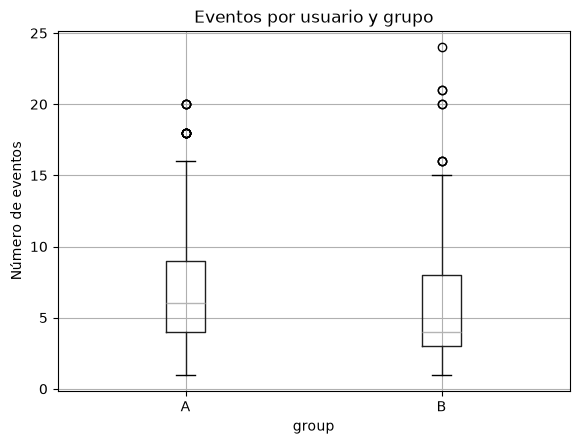

In [22]:

# Seleccionar participantes que cumplen los criterios de la prueba.
analysis_participants = test_cohort.loc[
    test_cohort['enrolment_in_window']
    & test_cohort['is_eu']
    & test_cohort['has_full_14d_window']
].copy()

# Identificar usuarios que participaron en otras pruebas.
other_test_users = participants.loc[
    participants['ab_test'] != 'recommender_system_test',
    'user_id'
].unique()

# Excluir de la cohorte a los usuarios de otras pruebas.
analysis_participants = analysis_participants.loc[
    ~analysis_participants['user_id'].isin(other_test_users)
].copy()

# Asociar los eventos con la cohorte analítica.
test_events = events.merge(
    analysis_participants,
    on='user_id',
    how='inner',
    validate='many_to_one'
)

# Conservar los eventos dentro de la ventana de 14 días.
test_events = test_events.loc[
    (test_events['event_dt'] >= test_events['first_date'])
    & (test_events['event_dt'] < test_events['window_end'])
].copy()

# Contar eventos por usuario, incluyendo usuarios sin eventos.
events_per_user = analysis_participants.merge(
    test_events.groupby('user_id').size().rename('n_events'), on='user_id', how='left'
).fillna({'n_events': 0})

# Resumir la actividad de cada grupo.
activity_summary = events_per_user.groupby('group')['n_events'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max'])

# Mostrar la comparación de actividad.
d(md("## **Actividad de Cada Grupo**"))
display(activity_summary.round(2))
print()

# Graficar la distribución para detectar diferencias visibles.
events_per_user.boxplot(column='n_events', by='group', grid=True)
plt.title('Eventos por usuario y grupo')
plt.suptitle('')  # Eliminar el título automático de pandas.
plt.ylabel('Número de eventos')
plt.show()

group,A,B
event_date,,
2020-12-07,221,268
2020-12-08,239,169
2020-12-09,282,250
2020-12-10,246,182
2020-12-11,264,115


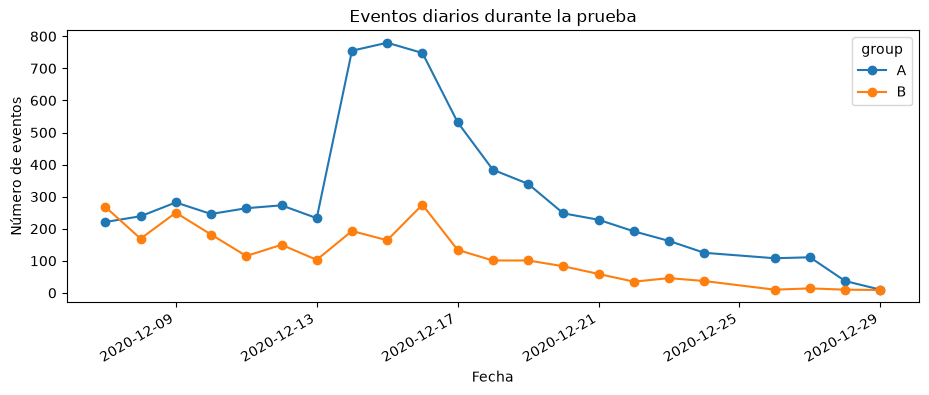

In [23]:
# Extraer la fecha de cada evento.
test_events['event_date'] = test_events['event_dt'].dt.normalize()

# Contar eventos diarios por grupo.
daily_events = test_events.groupby(
    ['event_date', 'group']).size().rename('n_events').reset_index()

# Reorganizar los datos para comparar ambos grupos.
daily_events_pivot = daily_events.pivot(
    index='event_date', columns='group', values='n_events').fillna(0)

# Mostrar la serie diaria.
d(daily_events_pivot.head())

# Graficar la evolución temporal de los eventos.
daily_events_pivot.plot(figsize=(11, 4), marker='o')

# Etiquetar los ejes.
plt.xlabel('Fecha')
plt.ylabel('Número de eventos')

# Agregar un título.
plt.title('Eventos diarios durante la prueba')

# Mostrar el gráfico.
plt.show()

In [24]:
# Calcular el límite superior de valores atípicos por grupo.
quartiles = events_per_user.groupby(
    'group')['n_events'].quantile([0.25, 0.75]).unstack()

# Obtener el límite usando el rango intercuartílico.
quartiles['upper_limit'] = quartiles[0.75] + \
    1.5 * (quartiles[0.75] - quartiles[0.25])

# Marcar usuarios con actividad inusualmente alta.
events_per_user['is_outlier'] = events_per_user.apply(
    lambda row: row['n_events'] > quartiles.loc[row['group'], 'upper_limit'], axis=1
)

# Resumir posibles anomalías por grupo.
anomalies = events_per_user.groupby('group').agg(
    usuarios=('user_id', 'nunique'),
    usuarios_atipicos=('is_outlier', 'sum'),
    proporcion_atipicos=('is_outlier', 'mean')
)

# Mostrar el peso de los usuarios atípicos.
display(anomalies.style.format({'proporcion_atipicos': '{:.2%}'}))

# Identificar el día con más eventos por grupo.
peak_days = daily_events.loc[daily_events.groupby('group')[
    'n_events'].idxmax()]

# Mostrar los picos de actividad diaria.
display(peak_days)

,usuarios,usuarios_atipicos,proporcion_atipicos
group,,,
A,969,12,1.24%
B,450,8,1.78%


,event_date,group,n_events
16,2020-12-15,A,780
19,2020-12-16,B,275


In [25]:
# Comprobar la coincidencia de las ventanas analíticas con la campaña de la UE.
promo = overlapping_campaigns.loc[
    overlapping_campaigns['name'].eq('Christmas&New Year Promo')
].iloc[0]

campaign_overlap = analysis_participants[[
    'user_id', 'group', 'first_date', 'window_end'
]].copy()

# La ventana de 14 días termina antes de window_end (límite exclusivo).
campaign_overlap['coincide_campana'] = (
    campaign_overlap['window_end'] > promo['start_dt']
) & (
    campaign_overlap['first_date'] < promo['finish_dt'] + pd.Timedelta(days=1)
)

campaign_overlap_summary = campaign_overlap.groupby('group')['coincide_campana'].agg(
    usuarios_coincidentes='sum', usuarios='count', proporcion='mean'
)

display(campaign_overlap_summary.style.format({'proporcion': '{:.2%}'}))

,usuarios_coincidentes,usuarios,proporcion
group,,,
A,625,969,64.50%
B,199,450,44.22%


<div style="border-left: 10px solid #616161;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

### **Conclusiones Parte 3.2 Actividad y distribución temporal de los eventos**

- El grupo **A presenta mayor actividad** que B, con un promedio de **6.73 eventos por usuario frente a 5.57**, aunque las distribuciones presentan un comportamiento relativamente similar.

- La actividad **no se distribuye uniformemente durante el período analizado**. Se observa un incremento de actividad durante diciembre y un **pico conjunto el 16 de diciembre**, seguido de una disminución posterior.

- Los usuarios atípicos representan una proporción **baja y similar entre ambos grupos**, por lo que no constituyen una diferencia relevante en el comportamiento de las muestras.

- Las ventanas de observación de **625 usuarios de A (64.50 %) y 199 de B (44.22 %)** coincidieron parcialmente con **Christmas&New Year Promo**. Esta diferencia temporal no acredita que los usuarios vieran la campaña ni demuestra un efecto causal sobre las conversiones.

- Las diferencias en el nivel de actividad y la concentración temporal de los eventos **deben considerarse al interpretar los resultados de la prueba A/B**.

**En conclusión, el grupo A presenta una actividad ligeramente mayor que B y los eventos muestran variaciones importantes a lo largo del tiempo. Sin embargo, no se identificaron diferencias relevantes en la proporción de usuarios atípicos que por sí mismas comprometan la comparación.**

</div>

### 3.3 Análisis del embudo de conversión

- **Identificación de las etapas del embudo:** analizar la participación de los usuarios en las tres etapas definidas para evaluar el comportamiento de la conversión: `product_page → product_cart → purchase`.

- **Cálculo de la conversión:** calcular, para los grupos A y B, la proporción de usuarios que registra cada evento respecto al total de usuarios de su grupo. Las proporciones son independientes por evento: no se exige que los usuarios hayan realizado los eventos anteriores ni que sigan un orden temporal; no se trata de un embudo secuencial.

- **Comparación entre los grupos:** comparar las tasas de conversión de A y B en cada etapa mediante la diferencia absoluta y la diferencia relativa, con el objetivo de identificar posibles mejoras o disminuciones asociadas al nuevo sistema.

- **Visualización del embudo:** representar gráficamente las tasas por evento para facilitar la comparación del comportamiento de ambos grupos.

In [26]:
# Identificar los eventos disponibles en los datos.
name_steps = events["event_name"].unique()
name_steps

<StringArray>
['purchase', 'product_cart', 'product_page', 'login']
Length: 4, dtype: str

In [27]:
# Definir las etapas del embudo.
funnel_steps = ['product_page', 'product_cart', 'purchase']
funnel_steps

['product_page', 'product_cart', 'purchase']

In [28]:
# Conservar solo eventos de las etapas definidas.
funnel_events = test_events.loc[test_events['event_name'].isin(funnel_steps)]

# Contar usuarios únicos que alcanzan cada etapa.
funnel_users = funnel_events.groupby(['group', 'event_name'])[
    'user_id'].nunique().rename('usuarios').reset_index()

# Calcular el total de usuarios asignados por grupo.
group_totals = analysis_participants.groupby(
    'group')['user_id'].nunique().rename('total_grupo')

# Agregar el total de cada grupo al embudo.
funnel_users = funnel_users.merge(group_totals, on='group')

# Calcular la conversión respecto al total del grupo.
funnel_users['conversion'] = funnel_users['usuarios'] / \
    funnel_users['total_grupo']

# Ordenar las etapas del embudo.
funnel_users['event_name'] = pd.Categorical(
    funnel_users['event_name'], categories=funnel_steps, ordered=True)

# Mostrar usuarios y conversión por etapa.
display(funnel_users.sort_values(
    ['event_name', 'group']).style.format({'conversion': '{:.2%}'}))

,group,event_name,usuarios,total_grupo,conversion
1,A,product_page,623,969,64.29%
4,B,product_page,253,450,56.22%
0,A,product_cart,300,969,30.96%
3,B,product_cart,125,450,27.78%
2,A,purchase,286,969,29.51%
5,B,purchase,124,450,27.56%


In [29]:
# Reorganizar las conversiones para comparar A y B.
conversion_comparison = funnel_users.pivot(
    index='event_name', columns='group', values='conversion').reindex(funnel_steps)

# Calcular la diferencia absoluta de B respecto a A.
conversion_comparison['diferencia_absoluta'] = conversion_comparison['B'] - \
    conversion_comparison['A']

# Calcular la diferencia relativa de B respecto a A.
conversion_comparison['diferencia_relativa'] = conversion_comparison['diferencia_absoluta'] / \
    conversion_comparison['A']

# Mostrar la comparación entre grupos.
display(conversion_comparison.style.format('{:.2%}'))

group,A,B,diferencia_absoluta,diferencia_relativa
event_name,,,,
product_page,64.29%,56.22%,-8.07%,-12.55%
product_cart,30.96%,27.78%,-3.18%,-10.28%
purchase,29.51%,27.56%,-1.96%,-6.64%


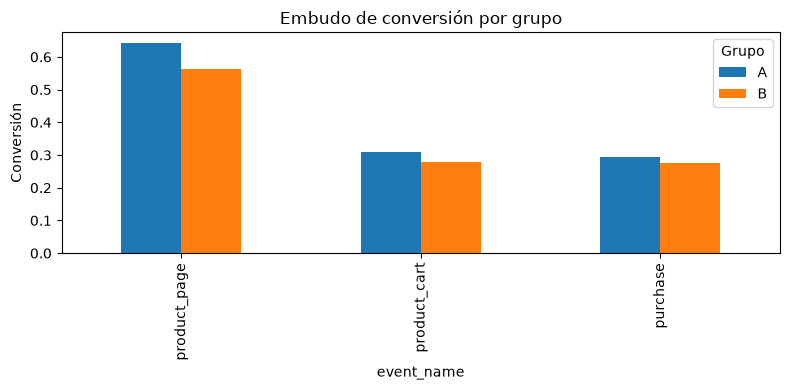

In [30]:
# Seleccionar las conversiones de ambos grupos.
funnel_plot = conversion_comparison[['A', 'B']]

# Graficar la progresión de cada grupo.
funnel_plot.plot(kind='bar', figsize=(8, 4))
plt.ylabel('Conversión')
plt.title('Embudo de conversión por grupo')
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

<div style="border-left: 10px solid #616161;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

### **Conclusiones Parte 3.3 Análisis del embudo de conversión**

- El grupo **A presenta una mayor conversión que B en las tres etapas del embudo**: `product_page` (**64.29% vs. 56.22%**), `product_cart` (**30.96% vs. 27.78%**) y `purchase` (**29.51% vs. 27.56%**).

- La diferencia relativa de B respecto a A es negativa en todas las etapas: **−12.55% en `product_page`**, **−10.28% en `product_cart`** y **−6.64% en `purchase`**.

- Por lo tanto, el grupo B **no alcanza el incremento esperado del 10% en ninguna de las etapas del embudo**.

- La menor proporción de usuarios de B se observa en los tres tipos de evento, incluida la compra; estas tasas no verifican un recorrido secuencial de los usuarios.

**En conclusión, el análisis descriptivo del embudo no muestra una mejora asociada al nuevo sistema de recomendaciones. Por el contrario, B presenta menores tasas de conversión en las tres etapas analizadas, por lo que los resultados no respaldan descriptivamente el objetivo planteado para el experimento.**

</div>

<div style="border-left: 10px solid #2196F3;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

## **Conclusiones Parte 3. Análisis Exploratorio de Datos**

- El análisis permitió identificar **condiciones relevantes en la población experimental**, principalmente el desbalance entre los grupos, la presencia de usuarios compartidos con otras pruebas y la necesidad de trabajar con una población que disponga de una ventana completa de observación de 14 días.

- La actividad de los usuarios fue ligeramente mayor en A, con **6.73 eventos por usuario frente a 5.57 en B**, mientras que la distribución temporal mostró un pico conjunto de eventos el **16 de diciembre**. Los usuarios atípicos representaron una proporción reducida y similar entre ambos grupos.

- En el embudo de conversión, **B presentó menores tasas que A en las tres etapas**: `product_page` (**56.22% vs. 64.29%**), `product_cart` (**27.78% vs. 30.96%**) y `purchase` (**27.56% vs. 29.51%**). Las diferencias relativas fueron de **−12.55%**, **−10.28%** y **−6.64%**, respectivamente.

**En conjunto, el EDA muestra que la prueba presenta algunas condiciones que deben considerarse al interpretar sus resultados y que, a nivel descriptivo, el nuevo sistema de recomendaciones no alcanza la mejora esperada del 10%. El grupo B presenta menores tasas de conversión en todas las etapas del embudo, por lo que no se observa evidencia descriptiva de una mejora antes de realizar la evaluación estadística.**

</div>

## Parte 4. Evaluación estadística de la prueba A/B

Una vez validada la población y documentadas las condiciones relevantes del experimento, se evaluará estadísticamente si las diferencias de conversión entre los grupos A y B pueden atribuirse al efecto de la variante experimental. <br>
La comparación se realizará mediante una prueba z para diferencia entre proporciones.

### Planteamiento de Hipótesis
- Para cada etapa del embudo se evaluará si el grupo B presenta una mayor conversión que el grupo A. <br>
- Se utilizará un nivel de significancia de **α = 0.05**. <br>

- El resultado estadístico se complementará con el criterio de éxito establecido en la prueba: <br>
	`Alcanzar un incremento relativo de al menos **10 %** en cada etapa del embudo.`




**H₀ (hipótesis nula):** <br>
	La conversión del grupo B no es superior a la del grupo A.

**H₁ (hipótesis alternativa):** <br>
	La conversión del grupo B es superior a la del grupo A.

### 4.1 Prueba z para diferencia entre grupos

Para cada etapa del embudo se aplicará una prueba z con α = 0.05. Se reportarán el estadístico y el p-value para determinar si la diferencia entre A y B es significativa.

In [31]:
# nivel de significancia.
alpha = 0.05

# Etapas del Embudo en variable funnel_steps

In [32]:
# Revisar los tamaños de muestra y conversiones por etapa.
display(
    funnel_users
    .sort_values(['event_name', 'group'])
    [['event_name', 'group', 'usuarios', 'total_grupo', 'conversion']]
)

,event_name,group,usuarios,total_grupo,conversion
1,product_page,A,623,969,0.642931
4,product_page,B,253,450,0.562222
0,product_cart,A,300,969,0.309598
3,product_cart,B,125,450,0.277778
2,purchase,A,286,969,0.295150
5,purchase,B,124,450,0.275556


In [33]:
# Definir lista vacía para resultados obtenidos
z_results = []

# Aplicar la prueba z a cada etapa del embudo mediante un bucle.
for step in funnel_steps:

    # Seleccionar los datos de la etapa actual.
    step_data = funnel_users[
        funnel_users['event_name'] == step
    ]

    # Obtener los usuarios que alcanzaron la etapa en cada grupo.
    users_A = step_data.loc[
        step_data['group'] == 'A', 'usuarios'
    ].sum()

    users_B = step_data.loc[
        step_data['group'] == 'B', 'usuarios'
    ].sum()

    # Obtener el total de usuarios de cada grupo.
    total_A = analysis_participants.loc[
        analysis_participants['group'] == 'A', 'user_id'
    ].nunique()

    total_B = analysis_participants.loc[
        analysis_participants['group'] == 'B', 'user_id'
    ].nunique()

    # Aplicar la prueba z.
    z_stat, p_value = proportions_ztest(
        [users_B, users_A],
        [total_B, total_A],
        alternative='larger'
    )
    # Guardar los resultados.
    z_results.append({
        'etapa': step,
        'z_stat': z_stat,
        'p_value': p_value
    })

z_results = pd.DataFrame(z_results)
z_results

,etapa,z_stat,p_value
0,product_page,-2.910901,0.998198
1,product_cart,-1.217779,0.888346
2,purchase,-0.757786,0.775711


### 4.2 Criterio de éxito y conclusión

El resultado será favorable solo si B supera a A en al menos 10 % y la prueba z es significativa. La conclusión indicará si existe evidencia de mejora, considerando las limitaciones identificadas en el EDA.

In [34]:
# Obtener las conversiones de A y B por etapa.
conversion_comparison = (
    funnel_users
    .pivot(index='event_name', columns='group', values='conversion')
    .reindex(funnel_steps)
)

# Calcular el cambio relativo de B respecto de A.
conversion_comparison['incremento_relativo'] = (
    conversion_comparison['B'] / conversion_comparison['A'] - 1
)

# Incorporar los resultados estadísticos.
success_results = conversion_comparison[[
    'A', 'B', 'incremento_relativo']].copy()

success_results['z_stat'] = z_results['z_stat'].values
success_results['p_value'] = z_results['p_value'].values

# Evaluar cada condición del criterio de éxito.
success_results['alcanza_10pct'] = (
    success_results['incremento_relativo'] >= 0.10
)

success_results['significativo'] = (
    success_results['p_value'] < alpha
)

success_results['cumple_criterio'] = (
    success_results['alcanza_10pct'] &
    success_results['significativo']
)

# Mostrar la evaluación final.
display(
    success_results.style.format({
        'A': '{:.2%}',
        'B': '{:.2%}',
        'incremento_relativo': '{:.2%}',
        'z_stat': '{:.3f}',
        'p_value': '{:.4f}'
    })
)

group,A,B,incremento_relativo,z_stat,p_value,alcanza_10pct,significativo,cumple_criterio
event_name,,,,,,,,
product_page,64.29%,56.22%,-12.55%,-2.911,0.9982,False,False,False
product_cart,30.96%,27.78%,-10.28%,-1.218,0.8883,False,False,False
purchase,29.51%,27.56%,-6.64%,-0.758,0.7757,False,False,False


<div style="border-left: 10px solid #2196F3;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

## **Conclusiones Parte 4. Evaluación estadística de la prueba A/B**
- La prueba z se realizó con un nivel de significancia de α = 0.05 para determinar si el grupo B presentaba una conversión significativamente mayor que el grupo A en cada etapa del embudo.
- En product_page, el p-value fue de 0.9982. No se encontró evidencia estadísticamente significativa de una mejora de B respecto a A. La conversión observada de B fue un 12.55 % menor que la de A.
- En product_cart y purchase, los p-values fueron de 0.8883 y 0.7757, respectivamente. Tampoco se encontró evidencia estadísticamente significativa de una mejora de B en estas etapas.
- Ninguna etapa cumple el criterio de éxito del experimento: B no alcanza un incremento mínimo del 10 % respecto a A ni presenta evidencia estadística suficiente de una mejora.
- La diferente coincidencia de las ventanas de observación con **Christmas&New Year Promo** (64.50 % en A y 44.22 % en B) debe considerarse al interpretar los resultados; no demuestra una influencia causal de la campaña.
En conclusión, la evaluación estadística no respalda que el nuevo sistema de recomendaciones haya mejorado la conversión. No se rechazó la hipótesis nula en ninguna de las tres etapas analizadas y las tasas de conversión observadas fueron menores en B que en A.

</div>

<div style="border-left: 10px solid #4CAF50;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

## **Parte 5. Conclusiones Generales del Proyecto**

Conclusiones Generales del Proyecto
- El experimento A/B tuvo como objetivo determinar si la introducción de un sistema de recomendaciones mejorado podía incrementar en al menos un 10% la conversión de los usuarios en las etapas product_page → product_cart → purchase.
- Después de aplicar los criterios de selección definidos para el análisis, se obtuvo una cohorte analítica de 1,419 usuarios, distribuida en 969 usuarios en A (68.29%) y 450 en B (31.71%). La diferencia en el tamaño de los grupos representa una condición que debe considerarse al interpretar los resultados.
- El análisis también identificó condiciones que podían afectar la comparación, como la presencia de usuarios compartidos con otras pruebas y la necesidad de disponer de una ventana completa de observación de 14 días. Además, las ventanas del 64.50 % de A y del 44.22 % de B coincidieron parcialmente con Christmas&New Year Promo; esto representa una diferencia temporal, sin demostrar exposición efectiva ni un efecto causal de la campaña.
- En cuanto a la actividad, el grupo A registró un promedio de 6.73 eventos por usuario, frente a 5.57 en B. La distribución temporal mostró variaciones importantes durante el período analizado, con un pico conjunto de actividad el 16 de diciembre. La proporción de usuarios atípicos fue baja y similar entre ambos grupos.
- A nivel descriptivo, el grupo B presentó menores tasas de conversión en las tres etapas del embudo. En product_page, la conversión fue de 56.22% en B frente a 64.29% en A, en product_cart fue de 27.78% frente a 30.96%, y en purchase de 27.56% frente a 29.51%. Esto representa diferencias relativas de −12.55%, −10.28% y −6.64%, respectivamente.
- La evaluación estadística mediante una prueba z unilateral para diferencia entre proporciones, con un nivel de significancia de α = 0.05, no encontró evidencia estadísticamente significativa de una mejora de B respecto a A en ninguna etapa del embudo. Los p-values fueron de 0.9982 en product_page, 0.8883 en product_cart y 0.7757 en purchase. Por lo tanto, no se rechazó la hipótesis nula en ninguna de las tres etapas.
### Veredicto final
- En función de la evidencia disponible, el experimento no cumple el criterio de éxito establecido. El grupo B no alcanzó un incremento mínimo del 10% en ninguna de las etapas del embudo y tampoco presentó evidencia estadística de una mejora frente al grupo A.
- Por lo tanto, no se recomienda adoptar el nuevo sistema de recomendaciones basándose en los resultados de esta prueba. Sin embargo, el resultado debe interpretarse considerando las condiciones identificadas durante el análisis exploratorio. Para obtener evidencia más concluyente, sería recomendable repetir el experimento con grupos mejor equilibrados, asignación exclusiva de los usuarios, una población correctamente definida y una ventana de observación completa, controlando además posibles factores externos como campañas de marketing.

</div>

<div style="border-left: 10px solid #4CAF50;padding: 20px;background: #D6D6D6;border-radius: 8px;color: #000000;word-wrap: break-word;overflow-wrap: break-word;white-space: normal;max-width: 98%;box-sizing: border-box;font-size: 15px;line-height: 1.6;text-align: justify;">

## **Insights Principales**

---

### **1. El nuevo sistema presenta menores tasas de conversión en todas las etapas**

- El grupo **B presentó menores tasas de conversión que A en las tres etapas del embudo**: `product_page` (**56.22% vs. 64.29%**), `product_cart` (**27.78% vs. 30.96%**) y `purchase` (**27.56% vs. 29.51%**). Las diferencias relativas fueron de **−12.55%**, **−10.28%** y **−6.64%**, respectivamente. Por lo tanto, el nuevo sistema no alcanzó la mejora esperada del 10%.<br>
**Recomendación:** No implementar el nuevo sistema como una mejora de conversión con base en esta prueba y revisar las condiciones del experimento antes de realizar un nuevo despliegue.

---

### **2. La menor conversión de B se observa en los tres tipos de evento**

- La diferencia desfavorable para B se observa en `product_page`, `product_cart` y `purchase`. Aunque su magnitud disminuye entre estas mediciones, B presenta una menor proporción de usuarios con compras registradas: **27.56% frente a 29.51%**. Estas tasas por evento no comprueban un recorrido secuencial.<br>
**Recomendación:** Analizar el recorrido de los usuarios de B entre las etapas del embudo para identificar posibles puntos de fricción asociados al nuevo sistema de recomendaciones.

---

### **3. No se encontró evidencia estadísticamente significativa de una mejora del grupo B**

- La prueba z unilateral no encontró evidencia estadísticamente significativa de que B presentara una conversión superior a A en ninguna etapa del embudo. Los *p-values* fueron de **0.9982** en `product_page`, **0.8883** en `product_cart` y **0.7757** en `purchase`, todos superiores al nivel de significancia de **α = 0.05**. Además, las tasas de conversión observadas fueron menores en B que en A.<br>
**Recomendación:** No interpretar las diferencias observadas como evidencia estadística de una mejora del nuevo sistema. Los resultados tampoco permiten afirmar, mediante esta prueba unilateral, que A sea estadísticamente superior a B.

---

### **4. El desbalance entre los grupos limita la solidez de la comparación**

- La cohorte analítica quedó conformada por **969 usuarios en A (68.29%) y 450 en B (31.71%)**, lo que representa una diferencia de **36.58 puntos porcentuales** entre los grupos. Esta distribución desigual debe considerarse al interpretar las diferencias observadas.<br>
**Recomendación:** En una nueva prueba, procurar una asignación más equilibrada y exclusiva de los participantes para mejorar la comparabilidad entre los grupos.

---

### **5. La actividad de los usuarios y su distribución temporal presentan diferencias que deben considerarse**

- El grupo A registró un promedio de **6.73 eventos por usuario**, frente a **5.57 en B**. Además, la actividad presentó variaciones importantes durante el período analizado, con un pico conjunto el **16 de diciembre**. Las ventanas del **64.50 % de A** y del **44.22 % de B** coincidieron parcialmente con **Christmas&New Year Promo**. Estas diferencias temporales deben considerarse al interpretar los resultados, sin atribuirles un efecto causal demostrado.<br>
**Recomendación:** Considerar la distribución temporal de la actividad y las condiciones externas del período al interpretar los resultados, especialmente cuando se comparen cambios en el comportamiento de los grupos.

---

**En conjunto, los insights muestran que el nuevo sistema de recomendaciones no alcanzó la mejora esperada y que las tasas de conversión observadas fueron menores en B que en A. La prueba z unilateral no encontró evidencia estadísticamente significativa de una mejora de B en ninguna etapa del embudo. Por ello, los resultados no respaldan la implementación del nuevo sistema como una mejora de conversión y sugieren la necesidad de repetir el experimento bajo condiciones experimentales más controladas.**

</div>